   Simulation   p_total  best_threshold  p_discretized_best  p_hacked
0           1  0.221115            38.1            0.002936      True
1           2  0.051177            35.3            0.001745      True
2           3  0.042752            34.5            0.002214     False
3           4  0.944589            20.5            0.105082     False
4           5  0.264147            34.1            0.018705      True
5           6  0.076821            36.9            0.000852      True
6           7  0.145125            30.3            0.007199      True
7           8  0.034140            18.5            0.010719     False
8           9  0.000123            36.7            0.000132     False
9          10  0.099694            18.0            0.004456      True

Simulácie, kde diskretizácia vytvorila signifikantný efekt:
    Simulation   p_total  best_threshold  p_discretized_best  p_hacked
0            1  0.221115            38.1            0.002936      True
1            2  0.051177   

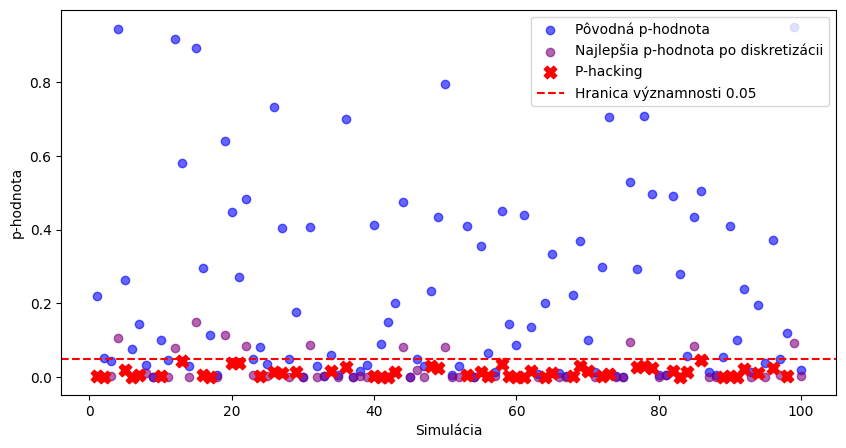

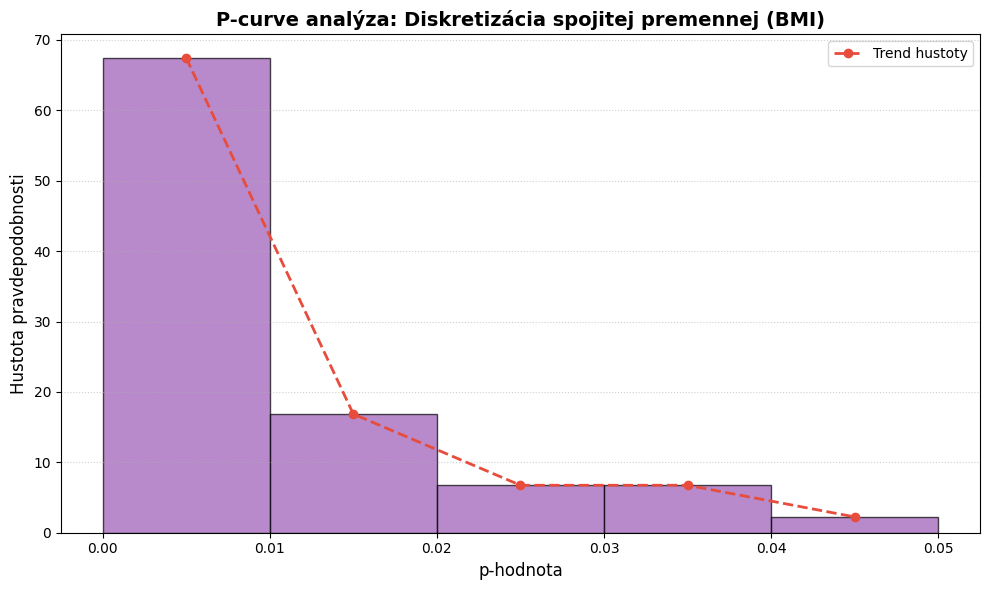

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath(".."))
import settings

# nacitanie suborov
def load_file(file_path):
    return pd.read_sas(file_path, format='xport')

def merge_files(file1, file2):
    return pd.merge(file1, file2[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

bmx = load_file(settings.bmx_path)
demo = load_file(settings.demo_path)
data = merge_files(bmx, demo)
data['gender_label'] = data['RIAGENDR'].map({1:"Men", 2:"Women"})

# parametre simulacie
dependent_var = 'BMXBMI'  
sample_size = 400
n_sim = 100
alpha = 0.05
n_bins = 2  # počet kategórií pre diskretizáciu 

# simulacia
results = []

for sim in range(n_sim):
    # náhodný výber vzorky
    sample = data.sample(sample_size, random_state=sim)

    # rozdelenie podla pohlavia
    men_total = sample[sample['gender_label']=='Men'][dependent_var].dropna()
    women_total = sample[sample['gender_label']=='Women'][dependent_var].dropna()

    # férový t-test 
    if len(men_total) > 1 and len(women_total) > 1:
        _, p_total = stats.ttest_ind(men_total, women_total)
    else:
        p_total = np.nan

    # hľadanie najlepšej hranice pre diskretizáciu
    all_vals = sample[dependent_var].dropna().sort_values().unique()
    best_p = np.nan
    best_thresh = None

    # skusame vsetky mozne sposoby ako diskretizovat BMI na vysoke a nizke
    for thresh in all_vals:
        # diskretizácia: 0 = pod hranicou, 1 = nad hranicou
        men_cat = (men_total > thresh).astype(int)
        women_cat = (women_total > thresh).astype(int)

        # t-test na kategorizovanej premenej
        if men_cat.nunique() > 1 and women_cat.nunique() > 1:
            t_stat, p_val = stats.ttest_ind(men_cat, women_cat)
            # vyber najlepsej hranice -> p-hacking
            if np.isnan(best_p) or p_val < best_p:
                best_p = p_val
                best_thresh = thresh

    # indikátor p-hackingu
    p_hacked = (best_p <= alpha) and (p_total > alpha)

    results.append({
        "Simulation": sim+1,
        "p_total": p_total,
        "best_threshold": best_thresh,
        "p_discretized_best": best_p,
        "p_hacked": p_hacked
    })

df = pd.DataFrame(results)

# Výpis tabuľky prvých 10 simulácií 
print(df.head(10))

# Tabuľka len hacknutých simulácií
df_hacked = df[df['p_hacked']]
print("\nSimulácie, kde diskretizácia vytvorila signifikantný efekt:")
print(df_hacked[['Simulation','p_total','best_threshold','p_discretized_best','p_hacked']])

# Graf p-hodnôt 
plt.figure(figsize=(10,5))

# pôvodná p-hodnota
plt.scatter(df['Simulation'], df['p_total'], alpha=0.6, label='Pôvodná p-hodnota', color='blue')

# najlepšia p-hodnota po diskretizácii
plt.scatter(df['Simulation'], df['p_discretized_best'], alpha=0.6, label='Najlepšia p-hodnota po diskretizácii', color='purple')

# hacknuté simulácie
plt.scatter(df_hacked['Simulation'], df_hacked['p_discretized_best'],
            color='red', s=80, label='P-hacking ', marker='X')

plt.axhline(alpha, color='red', linestyle='--', label='Hranica významnosti 0.05')
plt.xlabel('Simulácia')
plt.ylabel('p-hodnota')
plt.legend()
plt.savefig("phacking_diskretizacia", dpi=300)
plt.show()

#p-curve analýza

# len signifikantné p-hodnoty po diskretizácii
sig_p_diskret = df[df['p_discretized_best'] < 0.05]['p_discretized_best'].dropna()

if len(sig_p_diskret) > 0:
    plt.figure(figsize=(10, 6))
    
    # Histogram hustoty
    counts, bins, _ = plt.hist(sig_p_diskret, bins=5, range=(0, 0.05), 
                               color='#9b59b6', edgecolor='black', alpha=0.7, density=True)
    
    # Trendová čiara
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    plt.plot(bin_centers, counts, color='#e74c3c', marker='o', linestyle='--', linewidth=2, label='Trend hustoty')

    plt.title('P-curve analýza: Diskretizácia spojitej premennej (BMI)', fontsize=14, fontweight='bold')
    plt.xlabel('p-hodnota', fontsize=12)
    plt.ylabel('Hustota pravdepodobnosti', fontsize=12)
    plt.xticks(np.arange(0, 0.06, 0.01))
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.savefig("pcurve_diskretizacia.png", dpi=300)
    plt.show()
